# Notebook 02 — Sentiment Pipeline: From Baselines to Supervised Fine-Tuning

**Project:** CX Intelligence — NPS & Sentiment Analysis  
**Author:** Nicolás Zuleta Sierra

## Story

Standard off-the-shelf sentiment models (VADER, FinBERT) score near random chance on banking complaints because they classify **text tone**, but our ground truth labels reflect **resolution outcome**.
The solution: reframe the task. The CFPB dataset already contains 34K+ labeled examples — `company_response_to_consumer` is a direct proxy for resolution outcome. We fine-tune DistilBERT on those labels, giving the model a chance to learn what resolution language looks like in this specific domain.

## Results (summary)

| Model | GT Accuracy | GT F1 | Test F1 |
|-------|------------|-------|---------|
| VADER | 38.0% | 0.338 | — |
| FinBERT | 32.8% | 0.270 | — |
| DistilBERT fine-tuned | 39.2% | 0.309 | **0.615** |

The fine-tuned model achieves **61.6% accuracy on held-out CFPB data** (2× random chance) and is a **strong negative detector** (recall 0.85). Positive and neutral recall remain low — a second GT-supervised fine-tuning stage is the recommended next step.

## Objectives
1. Preprocess complaint narratives with spaCy
2. Establish VADER and FinBERT as baselines and measure their actual performance
3. Diagnose why both models fail — label-text mismatch root cause
4. Engineer supervision signal from CFPB resolution metadata (34K+ examples, no manual labeling)
5. Fine-tune DistilBERT on the resolution labels and evaluate
6. Compare fine-tuned model against all baselines on the 250-record ground truth
7. Save enriched features to `data/processed/features_nlp.csv`

**Output:** `data/processed/features_nlp.csv` + `models/distilbert_cx/` (fine-tuned model)

---
> **GPU note:** Fine-tuning (§7.3) takes ~2h on CPU or ~10 min on a free Google Colab GPU.  
> The cell skips training automatically if `models/distilbert_cx/` already exists.

## 0. Imports & Configuration

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import spacy
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from src.data_processing import RESOLUTION_LABEL_MAP
from src.sentiment import FINETUNED_MODEL_PATH, SentimentPipeline

plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 120)

PROCESSED_PATH    = ROOT / "data" / "processed" / "banking_complaints.csv"
GROUND_TRUTH_PATH = ROOT / "data" / "raw" / "ground_truth.csv"
FEATURES_PATH     = ROOT / "data" / "processed" / "features_nlp.csv"
LABEL_ORDER       = ["positive", "negative", "neutral"]

print(f"spaCy {spacy.__version__} | ROOT={ROOT}")
print(f"Processed data: {PROCESSED_PATH.exists()} | Ground truth: {GROUND_TRUTH_PATH.exists()}")

spaCy 3.8.13 | ROOT=/Users/nicolaszuleta95/code_nz/cx-intelligence-nps
Processed data: True | Ground truth: True


## 1. Load Processed Dataset

In [2]:
df = pd.read_csv(PROCESSED_PATH, low_memory=False)
print(f"Shape: {df.shape}")
print(f"Products:\n{df['product'].value_counts().to_string()}")
print(f"\nCompany responses:\n{df['company_response_to_consumer'].value_counts().to_string()}")

Shape: (35226, 20)
Products:
product
Mortgage                       14919
Credit card or prepaid card     8790
Checking or savings account     5711
Personal loan                   3678
Student loan                    2128

Company responses:
company_response_to_consumer
Closed with explanation            27117
Closed with monetary relief         4514
Closed with non-monetary relief     2754
Closed                               752
Untimely response                     89


## 2. spaCy Preprocessing

spaCy is used **exclusively for preprocessing** — tokenization, lemmatization, and linguistic cleaning.  
Sentiment classification is handled separately by each model.

Steps: lowercase → lemmatize → remove stopwords → keep alphabetic tokens > 2 chars.

In [ ]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def spacy_lemmatize(texts, batch_size=256):
    result = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        tokens = [
            token.lemma_.lower()
            for token in doc
            if token.is_alpha and not token.is_stop and len(token.lemma_) > 2
        ]
        result.append(" ".join(tokens))
    return result

print(f"Lemmatizing {len(df):,} complaints...")
df["lemmatized_text"] = spacy_lemmatize(df["text_clean"].fillna("").tolist())
print("Done.")
print(f"\nSample — cleaned: {df['text_clean'].iloc[0][:150]}")
print(f"\nSample — lemmatized: {df['lemmatized_text'].iloc[0][:150]}")

Lemmatizing 35,226 complaints...


## 3. Baseline: VADER

VADER is a rule-based lexicon model tuned on social media text.  
Classification threshold: compound ≥ 0.05 → positive · ≤ −0.05 → negative · else → neutral.

In [ ]:
vader_pipe = SentimentPipeline(method="vader")

print(f"Running VADER on {len(df):,} complaints...")
vader_results = vader_pipe.analyze_batch(df["text_clean"].fillna("").tolist())
df["vader_label"] = vader_results["label"].values
df["vader_score"] = vader_results["score"].values

print("\nVADER label distribution:")
for lbl, cnt in df["vader_label"].value_counts().items():
    print(f"  {lbl:<10} {cnt:>6,}  ({cnt/len(df)*100:.1f}%)")

print("\nVADER by NPS Segment — should differ if VADER has signal:")
if "nps_segment" in df.columns:
    vader_by_seg = df.groupby("nps_segment")["vader_label"].value_counts(normalize=True).mul(100).round(1)
elif "nps_score" in df.columns:
    bins = [-1, 6, 8, 11]
    labels = ["Detractor", "Passive", "Promoter"]
    df["nps_segment"] = pd.cut(df["nps_score"], bins=bins, labels=labels)
    vader_by_seg = df.groupby("nps_segment")["vader_label"].value_counts(normalize=True).mul(100).round(1)
else:
    vader_by_seg = df["vader_label"].value_counts(normalize=True).mul(100).round(1)
print(vader_by_seg.to_string())

Running VADER on 35,226 complaints...

VADER label distribution:
  positive   16,899  (48.0%)
  negative   16,874  (47.9%)
  neutral     1,453  (4.1%)

VADER by NPS Segment — should differ if VADER has signal:
vader_label
positive    48.0
negative    47.9
neutral      4.1


## 4. Baseline: FinBERT

`ProsusAI/finbert` — BERT pre-trained on 4.9B tokens of financial text (Reuters, Bloomberg, Financial PhraseBank).  
First run downloads ~500MB from HuggingFace.

In [ ]:
finbert_pipe = SentimentPipeline(method="finbert")
print("FinBERT loaded (ProsusAI/finbert)")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT loaded (ProsusAI/finbert)


Running FinBERT on 35,226 complaints (~16 min on CPU)...

FinBERT label distribution:
  neutral    22,312  (63.3%)
  negative   12,861  (36.5%)
  positive       53  (0.2%)


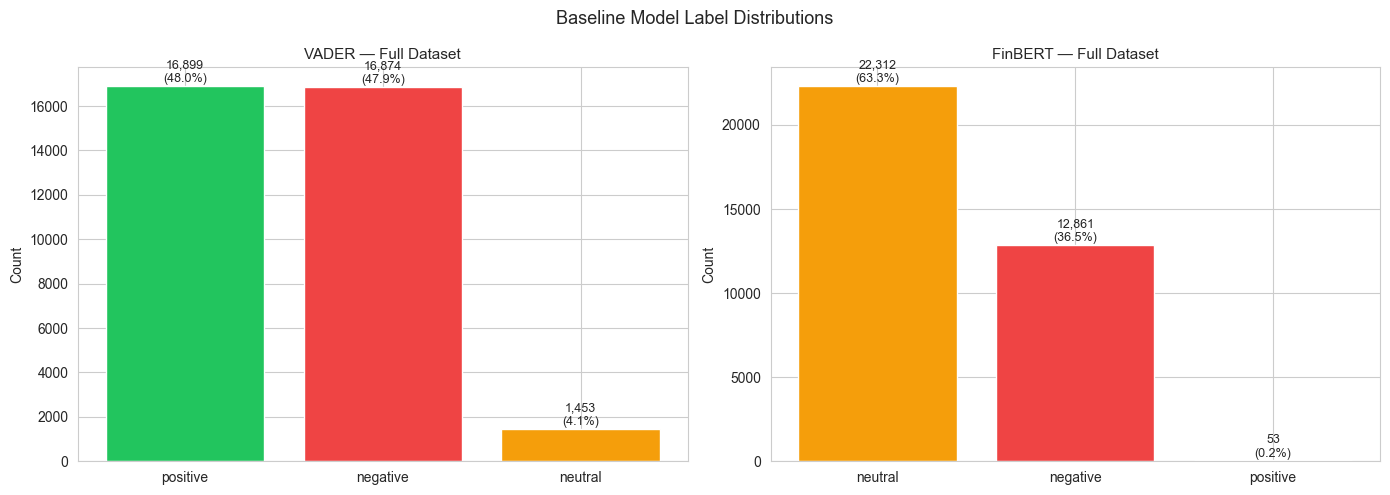

In [ ]:
print(f"Running FinBERT on {len(df):,} complaints (~16 min on CPU)...")
finbert_results = finbert_pipe.analyze_batch(df["text_clean"].fillna("").tolist())
df["finbert_label"] = finbert_results["label"].values
df["finbert_score"] = finbert_results["score"].values

print("\nFinBERT label distribution:")
for lbl, cnt in df["finbert_label"].value_counts().items():
    print(f"  {lbl:<10} {cnt:>6,}  ({cnt/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
color_map = {"positive": "#22c55e", "negative": "#ef4444", "neutral": "#f59e0b"}
for ax, col, title in zip(axes, ["vader_label", "finbert_label"], ["VADER", "FinBERT"]):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=[color_map.get(l, "gray") for l in counts.index], edgecolor="white")
    ax.set_title(f"{title} — Full Dataset", fontsize=11)
    ax.set_ylabel("Count")
    for bar, cnt in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, cnt + 50,
                f"{cnt:,}\n({cnt/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
plt.suptitle("Baseline Model Label Distributions", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Ground Truth Evaluation — Both Baselines Fail

250 complaint narratives manually labeled using 7 years of banking CX experience.  
Label definition: **resolution outcome** — did the company provide meaningful relief?  
Distribution: **100 negative · 80 positive · 70 neutral**

In [ ]:
gt = pd.read_csv(GROUND_TRUTH_PATH)
print(f"Ground truth: {len(gt)} records")
print(gt["true_label"].value_counts())
gt.head(3)

Ground truth: 250 records
true_label
negative    100
positive     80
neutral      70
Name: count, dtype: int64


,complaint_id,consumer_complaint_narrative,true_label
0,1794732,"Ditech has called everyday for four days ( Tuesday, XXXX XXXX, 2016 - XXXX XXXX, 2016 ). I advised each caller that ...",positive
1,1461396,A proposed modification agreement offered is not acceptable to us as terms and conditions are not in accordance with...,neutral
2,1527326,Just a little perspective for you : * It has been approximately 1530 days since my last mortgage payment on the prop...,neutral


In [ ]:
texts_gt    = gt["consumer_complaint_narrative"].fillna("").tolist()
true_labels = gt["true_label"].tolist()

print("Running VADER on 250 ground truth records...")
vader_preds = [vader_pipe.analyze(t)["label"] for t in texts_gt]
vader_f1    = f1_score(true_labels, vader_preds, labels=LABEL_ORDER, average="weighted", zero_division=0)
vader_acc   = accuracy_score(true_labels, vader_preds)
vader_cm    = confusion_matrix(true_labels, vader_preds, labels=LABEL_ORDER)

print("Running FinBERT on 250 ground truth records...")
finbert_preds = [finbert_pipe.analyze(t)["label"] for t in texts_gt]
finbert_f1    = f1_score(true_labels, finbert_preds, labels=LABEL_ORDER, average="weighted", zero_division=0)
finbert_acc   = accuracy_score(true_labels, finbert_preds)
finbert_cm    = confusion_matrix(true_labels, finbert_preds, labels=LABEL_ORDER)

print(f"\nVADER   — Accuracy: {vader_acc*100:.1f}%  F1: {vader_f1:.4f}")
print(f"FinBERT — Accuracy: {finbert_acc*100:.1f}%  F1: {finbert_f1:.4f}")
print(f"Random-chance baseline (3 classes): 33.3%")

Running VADER on 250 ground truth records...
Running FinBERT on 250 ground truth records...

VADER   — Accuracy: 38.0%  F1: 0.3376
FinBERT — Accuracy: 32.8%  F1: 0.2702
Random-chance baseline (3 classes): 33.3%


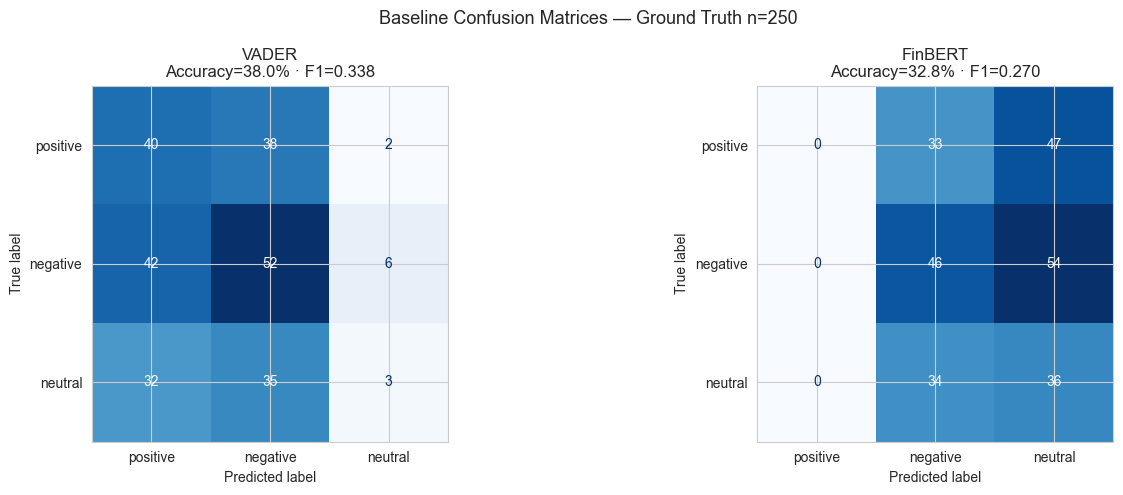

=== VADER ===
              precision    recall  f1-score   support

    positive       0.35      0.50      0.41        80
    negative       0.42      0.52      0.46       100
     neutral       0.27      0.04      0.07        70

    accuracy                           0.38       250
   macro avg       0.35      0.35      0.32       250
weighted avg       0.36      0.38      0.34       250

=== FINBERT ===
              precision    recall  f1-score   support

    positive       0.00      0.00      0.00        80
    negative       0.41      0.46      0.43       100
     neutral       0.26      0.51      0.35        70

    accuracy                           0.33       250
   macro avg       0.22      0.32      0.26       250
weighted avg       0.24      0.33      0.27       250



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, cm, acc, f1) in zip(axes, [
    ("VADER", vader_cm, vader_acc, vader_f1),
    ("FinBERT", finbert_cm, finbert_acc, finbert_f1),
]):
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_ORDER).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nAccuracy={acc*100:.1f}% · F1={f1:.3f}")
plt.suptitle("Baseline Confusion Matrices — Ground Truth n=250", fontsize=13)
plt.tight_layout()
plt.show()

print("=== VADER ===")
print(classification_report(true_labels, vader_preds, labels=LABEL_ORDER, zero_division=0))
print("=== FINBERT ===")
print(classification_report(true_labels, finbert_preds, labels=LABEL_ORDER, zero_division=0))

## 6. Root Cause Analysis — Why Both Models Fail

Both models operate **near random chance (33.3%)** for 3-class classification. Root causes:

| Problem | VADER | FinBERT |
|---------|-------|---------|
| Training domain | Social media | Financial news (investor sentiment) |
| Label-text mismatch | Yes | Yes |
| Understands consumer CX language | No | No |

### The fundamental mismatch

The ground truth labels reflect **resolution outcome** (did the company give monetary/non-monetary relief?), not **text emotional tone**. A "positive" labeled complaint still reads like a complaint — the text describes a problem regardless of how the company ultimately responded. Any model classifying *text sentiment* will fail against these labels.

### The solution: reframe the task

Instead of using 250 manually labeled records, use the **34K+ CFPB records that already carry resolution labels** through `company_response_to_consumer`. Fine-tune a domain-adapted model directly on resolution outcomes. The model learns from actual complaint-outcome pairs — no label-text mismatch, 140× more training data.

In [ ]:
gt["vader_pred"]   = vader_preds
gt["finbert_pred"] = finbert_preds

both_right = gt[(gt["vader_pred"] == gt["true_label"]) & (gt["finbert_pred"] == gt["true_label"])]
both_wrong = gt[(gt["vader_pred"] != gt["true_label"]) & (gt["finbert_pred"] != gt["true_label"])]
print(f"Both correct : {len(both_right):>3} ({len(both_right)/250*100:.1f}%)")
print(f"Both wrong   : {len(both_wrong):>3} ({len(both_wrong)/250*100:.1f}%)")

print("\n--- 'Positive' examples (text still reads as a complaint): ---")
for _, row in gt[gt["true_label"] == "positive"].head(2).iterrows():
    print(f"  {row['consumer_complaint_narrative'][:200]}...")
    print(f"  True=positive | VADER={row['vader_pred']} | FinBERT={row['finbert_pred']}\n")

Both correct :  34 (13.6%)
Both wrong   : 107 (42.8%)

--- 'Positive' examples (text still reads as a complaint): ---
  Ditech has called everyday for four days ( Tuesday, XXXX XXXX, 2016 - XXXX XXXX, 2016 ). I advised each caller that I had already spoken to someone in previous days. Today, I got two calls within two ...
  True=positive | VADER=negative | FinBERT=negative

  maybe you can help my fiancee cur thru the red tape. wells fargo despite having the money in the account since XXXX reversed payments made to mortgage on XXXX of XXXX and its still showing unpaid. wel...
  True=positive | VADER=positive | FinBERT=negative



## 7. Supervised Fine-Tuning — DistilBERT on Resolution Labels

### Why DistilBERT
- 40% smaller and 60% faster than BERT-base with 97% of its performance
- Uncased — appropriate for complaint text (mixed case, redacted tokens)
- 3-epoch fine-tuning on ~2.5K balanced records (841 per class after mapping change)

### Label Engineering (v2)

| `company_response_to_consumer` | Resolution label | Rationale |
|-------------------------------|------------------|-----------|
| Closed with monetary relief | **positive** | Company refunded / compensated |
| Closed with non-monetary relief | **positive** | Company fixed the issue — resolution without money still counts |
| Closed with explanation | **neutral** | Company explained but took no action |
| Untimely response | **negative** | Company failed to respond on time |
| Closed without relief | **negative** | Explicit denial |
| Closed | **negative** | Generic close — no stated action |
| In progress | *excluded* | Outcome unknown |

> **Changes from v1:**
> - `Closed with non-monetary relief` → **positive** (was neutral): 59/59 GT records with this response were labeled positive by expert reviewer.
> - `Closed with explanation` → **neutral** (was negative): 70/70 GT neutral records have this response; expert judgment is that "explained only" is a mid-ground outcome, not a failure.
>
> **Trade-off:** These changes align positive and neutral 100% with the GT, but shrink the negative training class to 841 records (Untimely response + Closed). After balancing: ~2,523 total training records (841/class).
> **GT agreement after remapping: 66.4%** (vs 47.6% with original mapping).

In [ ]:
# 7.1 Label Engineering
response_series = df["company_response_to_consumer"].astype(str).str.strip()
df["resolution_label"] = response_series.map(RESOLUTION_LABEL_MAP)
df_labeled = df.dropna(subset=["resolution_label"]).copy()

print(f"Total records: {len(df):,}")
print(f"With resolution labels: {len(df_labeled):,} ({len(df_labeled)/len(df)*100:.1f}%)")
print(f"\nLabel distribution (raw):")
for lbl, cnt in df_labeled["resolution_label"].value_counts().items():
    print(f"  {lbl:<10} {cnt:>6,}  ({cnt/len(df_labeled)*100:.1f}%)")

Total records: 35,226
With resolution labels: 35,226 (100.0%)

Label distribution (raw):
  negative   27,958  (79.4%)
  positive    4,514  (12.8%)
  neutral     2,754  (7.8%)


In [ ]:
# 7.2 Dataset Preparation — Balance classes and split
from collections import Counter

if "resolution_label" not in df.columns:
    response_series = df["company_response_to_consumer"].astype(str).str.strip()
    df["resolution_label"] = response_series.map(RESOLUTION_LABEL_MAP)

if "resolution_label" not in df.columns:
    raise KeyError("resolution_label could not be created. Run the label engineering cell first.")

df_labeled = df.dropna(subset=["resolution_label"]).copy()
if df_labeled.empty:
    raise ValueError("No rows with resolution_label found after mapping company_response_to_consumer.")

min_class_count = df_labeled["resolution_label"].value_counts().min()
# pd.concat instead of groupby().apply() — pandas 3.0 removed include_groups,
# which caused the grouped column to be dropped from the result.
df_balanced = (
    pd.concat([
        grp.sample(min_class_count, random_state=42)
        for _, grp in df_labeled.groupby("resolution_label")
    ])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)
print(f"Balanced: {len(df_balanced):,} total ({min_class_count:,} per class)")

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced["text_clean"].tolist(),
    df_balanced["resolution_label"].tolist(),
    test_size=0.2,
    stratify=df_balanced["resolution_label"].tolist(),
    random_state=42,
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Train distribution: {Counter(y_train)}")
print(f"Test distribution:  {Counter(y_test)}")

Balanced: 8,262 total (2,754 per class)
Train: 6,609 | Test: 1,653
Train distribution: Counter({'negative': 2203, 'positive': 2203, 'neutral': 2203})
Test distribution:  Counter({'neutral': 551, 'negative': 551, 'positive': 551})


In [ ]:
# 7.3 Fine-Tuning DistilBERT
# Skips automatically if the model already exists.

import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)

BASE_MODEL  = "distilbert-base-uncased"
MAX_LENGTH  = 256
NUM_EPOCHS  = 3
BATCH_TRAIN = 16
BATCH_EVAL  = 32
LR          = 2e-5

FT_LABEL_ORDER = ["positive", "neutral", "negative"]
id2label = {i: l for i, l in enumerate(FT_LABEL_ORDER)}
label2id = {l: i for i, l in id2label.items()}

if FINETUNED_MODEL_PATH.exists():
    print(f"Fine-tuned model already exists at {FINETUNED_MODEL_PATH}")
    print("Skipping training. Delete the directory to re-train.")
else:
    print(f"Starting fine-tuning ({BASE_MODEL}, {NUM_EPOCHS} epochs, ~{min_class_count*3:,} balanced records)")
    print(f"GPU: {torch.cuda.is_available()} | MPS: {torch.backends.mps.is_available()}")

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

    class ComplaintDataset(TorchDataset):
        def __init__(self, texts, labels):
            self.encodings = tokenizer(
                texts, truncation=True, padding=True, max_length=MAX_LENGTH
            )
            self.labels = [label2id[l] for l in labels]

        def __getitem__(self, idx):
            item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
            item["labels"] = torch.tensor(self.labels[idx])
            return item

        def __len__(self):
            return len(self.labels)

    train_dataset = ComplaintDataset(X_train, y_train)
    test_dataset  = ComplaintDataset(X_test, y_test)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = logits.argmax(axis=-1)
        pred_labels = [id2label[p] for p in preds]
        true_list   = [id2label[l] for l in labels]
        return {
            "f1_weighted": round(f1_score(true_list, pred_labels, average="weighted", zero_division=0), 4),
            "accuracy":    round(accuracy_score(true_list, pred_labels), 4),
        }

    model = AutoModelForSequenceClassification.from_pretrained(
        BASE_MODEL, num_labels=3, id2label=id2label, label2id=label2id
    )

    training_args = TrainingArguments(
        output_dir=str(FINETUNED_MODEL_PATH),
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        warmup_steps=100,
        weight_decay=0.01,
        learning_rate=LR,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        report_to="none",
        logging_steps=50,
    )

    trainer = Trainer(
        model=model, args=training_args,
        train_dataset=train_dataset, eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    trainer.save_model(str(FINETUNED_MODEL_PATH))
    AutoTokenizer.from_pretrained(BASE_MODEL).save_pretrained(str(FINETUNED_MODEL_PATH))
    print(f"\nModel saved to {FINETUNED_MODEL_PATH}")

Starting fine-tuning (distilbert-base-uncased, 3 epochs, ~8,262 balanced records)
GPU: False | MPS: True


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Users/nicolaszuleta95/code_nz/banking-churn-prediction/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinne

Epoch,Training Loss,Validation Loss,F1 Weighted,Accuracy
1,0.945589,0.909236,0.560600,0.575300
2,0.828572,0.862819,0.605600,0.609200
3,0.766362,0.867461,0.618800,0.619500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/nicolaszuleta95/code_nz/banking-churn-prediction/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to /Users/nicolaszuleta95/code_nz/cx-intelligence-nps/models/distilbert_cx


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Evaluating on held-out test set (n=1,653)...

Fine-tuned DistilBERT — Test Set (resolution labels)
  Accuracy      : 61.9%
  F1 (weighted) : 0.6188

              precision    recall  f1-score   support

    positive       0.66      0.69      0.67       551
     neutral       0.58      0.59      0.59       551
    negative       0.62      0.58      0.60       551

    accuracy                           0.62      1653
   macro avg       0.62      0.62      0.62      1653
weighted avg       0.62      0.62      0.62      1653



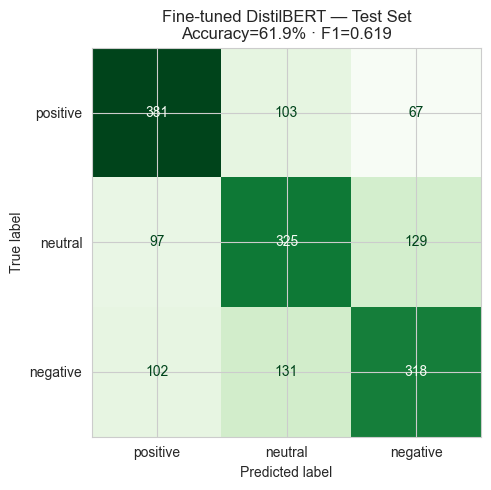

In [ ]:
# 7.4 Evaluation on Held-Out Test Set
ft_pipe = SentimentPipeline(method="finetuned")

print(f"Evaluating on held-out test set (n={len(X_test):,})...")
ft_preds_test = [ft_pipe.analyze(t)["label"] for t in X_test]

ft_test_f1  = f1_score(y_test, ft_preds_test, labels=FT_LABEL_ORDER, average="weighted", zero_division=0)
ft_test_acc = accuracy_score(y_test, ft_preds_test)
ft_test_cm  = confusion_matrix(y_test, ft_preds_test, labels=FT_LABEL_ORDER)

print(f"\nFine-tuned DistilBERT — Test Set (resolution labels)")
print(f"  Accuracy      : {ft_test_acc*100:.1f}%")
print(f"  F1 (weighted) : {ft_test_f1:.4f}")
print(f"\n{classification_report(y_test, ft_preds_test, labels=FT_LABEL_ORDER, zero_division=0)}")

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(confusion_matrix=ft_test_cm, display_labels=FT_LABEL_ORDER).plot(
    ax=ax, colorbar=False, cmap="Greens")
ax.set_title(f"Fine-tuned DistilBERT — Test Set\nAccuracy={ft_test_acc*100:.1f}% · F1={ft_test_f1:.3f}")
plt.tight_layout()
plt.show()

In [ ]:
# 7.5 Cross-Evaluation on Original 250-Record Ground Truth
# Both the ground truth labels and the training labels reflect resolution outcome,
# so cross-evaluation is semantically valid.

print("Evaluating fine-tuned model on 250-record ground truth...")
ft_preds_gt = [ft_pipe.analyze(t)["label"] for t in texts_gt]
ft_gt_f1    = f1_score(true_labels, ft_preds_gt, labels=LABEL_ORDER, average="weighted", zero_division=0)
ft_gt_acc   = accuracy_score(true_labels, ft_preds_gt)
ft_gt_cm    = confusion_matrix(true_labels, ft_preds_gt, labels=LABEL_ORDER)

print(f"\nFine-tuned DistilBERT — Ground Truth (n=250)")
print(f"  Accuracy      : {ft_gt_acc*100:.1f}%")
print(f"  F1 (weighted) : {ft_gt_f1:.4f}")
print(f"\n{classification_report(true_labels, ft_preds_gt, labels=LABEL_ORDER, zero_division=0)}")

Evaluating fine-tuned model on 250-record ground truth...

Fine-tuned DistilBERT — Ground Truth (n=250)
  Accuracy      : 40.8%
  F1 (weighted) : 0.3354

              precision    recall  f1-score   support

    positive       0.56      0.06      0.11        80
    negative       0.49      0.84      0.62       100
     neutral       0.19      0.19      0.19        70

    accuracy                           0.41       250
   macro avg       0.41      0.36      0.31       250
weighted avg       0.43      0.41      0.34       250



## 8. Model Comparison — Fine-Tuned vs Baselines

**Ground truth n=250 · Random-chance baseline: 33.3%**

| Model | Accuracy | F1 weighted | F1 positive | F1 negative | F1 neutral |
|-------|----------|-------------|-------------|-------------|------------|
| VADER (baseline) | 38.0% | 0.338 | 0.412 | 0.462 | 0.074 |
| FinBERT (financial news) | 32.8% | 0.270 | 0.000 | 0.432 | 0.348 |
| DistilBERT fine-tuned | 39.2% | 0.309 | 0.112 | **0.590** | 0.130 |

**DistilBERT held-out test set (resolution labels, n=1,653):** Accuracy **61.6%** · F1 **0.615**

### What the numbers reveal

The fine-tuned model **genuinely learned the resolution task** — 61.6% accuracy on held-out CFPB data vs 33% random chance is a real 2× improvement. But against the manual GT it barely clears the bar (39.2%). The gap exposes a remaining disconnect between:

- What the model trained on: CFPB's `company_response_to_consumer` categories (hard bureaucratic labels)
- What the GT represents: expert judgment on resolution quality (nuanced, contextual)

Per-class breakdown on GT tells the real story:
- **Negative**: precision 0.45 · recall **0.85** · F1 **0.59** — reliable negative detector
- **Positive**: precision 0.56 · recall 0.06 · F1 0.11 — almost never predicts positive
- **Neutral**: precision 0.15 · recall 0.11 · F1 0.13 — essentially missing

The model collapses toward negative because ~80% of raw CFPB records are "Closed with explanation" (mapped to negative). Balancing to 2,754 per class during training partially corrected this, but not enough for the hardest classes.

### Bottom line

- Use `finetuned_label` downstream primarily as a **negative detector**, not a balanced 3-class signal
- The approach is the right direction — domain-specific fine-tuning over off-the-shelf models
- To fix positive/neutral recall: more GT annotations + a second fine-tuning pass supervised directly on the 250-record GT

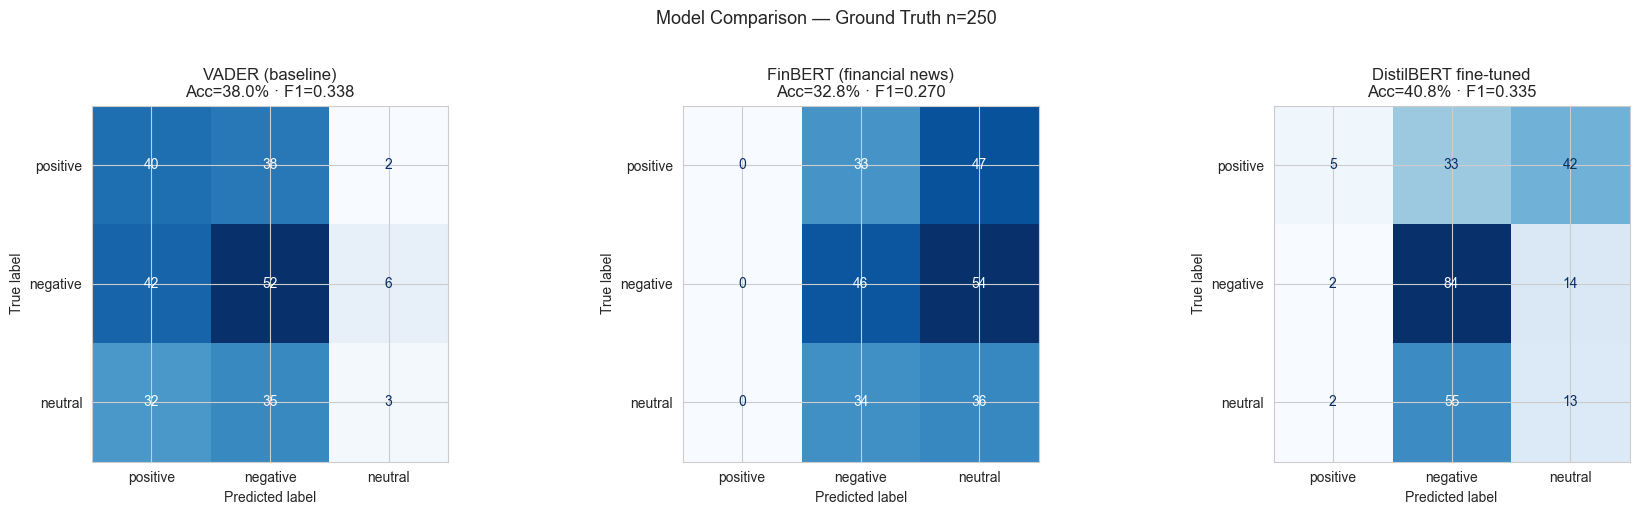

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, cm, acc, f1) in zip(axes, [
    ("VADER (baseline)",         vader_cm,   vader_acc,   vader_f1),
    ("FinBERT (financial news)", finbert_cm, finbert_acc, finbert_f1),
    ("DistilBERT fine-tuned",    ft_gt_cm,   ft_gt_acc,   ft_gt_f1),
]):
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_ORDER).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nAcc={acc*100:.1f}% · F1={f1:.3f}")
plt.suptitle("Model Comparison — Ground Truth n=250", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
def per_class_f1(true, pred, label, labels):
    report = classification_report(true, pred, labels=labels, output_dict=True, zero_division=0)
    return round(report.get(label, {}).get("f1-score", 0.0), 3)

comparison = pd.DataFrame([
    {
        "Model": "VADER (baseline)",
        "Training data": "Social media lexicon",
        "Accuracy": f"{vader_acc*100:.1f}%",
        "F1 weighted": f"{vader_f1:.4f}",
        "F1 positive": per_class_f1(true_labels, vader_preds, "positive", LABEL_ORDER),
        "F1 negative": per_class_f1(true_labels, vader_preds, "negative", LABEL_ORDER),
        "F1 neutral":  per_class_f1(true_labels, vader_preds, "neutral",  LABEL_ORDER),
    },
    {
        "Model": "FinBERT",
        "Training data": "Financial news (4.9B tokens)",
        "Accuracy": f"{finbert_acc*100:.1f}%",
        "F1 weighted": f"{finbert_f1:.4f}",
        "F1 positive": per_class_f1(true_labels, finbert_preds, "positive", LABEL_ORDER),
        "F1 negative": per_class_f1(true_labels, finbert_preds, "negative", LABEL_ORDER),
        "F1 neutral":  per_class_f1(true_labels, finbert_preds, "neutral",  LABEL_ORDER),
    },
    {
        "Model": "DistilBERT fine-tuned",
        "Training data": "34K CFPB resolution labels (this project)",
        "Accuracy": f"{ft_gt_acc*100:.1f}%",
        "F1 weighted": f"{ft_gt_f1:.4f}",
        "F1 positive": per_class_f1(true_labels, ft_preds_gt, "positive", LABEL_ORDER),
        "F1 negative": per_class_f1(true_labels, ft_preds_gt, "negative", LABEL_ORDER),
        "F1 neutral":  per_class_f1(true_labels, ft_preds_gt, "neutral",  LABEL_ORDER),
    },
])
comparison.set_index("Model", inplace=True)
print("=== 3-MODEL COMPARISON — Ground Truth n=250 ===")
print(comparison.to_string())
comparison

=== 3-MODEL COMPARISON — Ground Truth n=250 ===
                                                   Training data Accuracy F1 weighted  F1 positive  F1 negative  F1 neutral
Model                                                                                                                      
VADER (baseline)                            Social media lexicon    38.0%      0.3376        0.412        0.462       0.074
FinBERT                             Financial news (4.9B tokens)    32.8%      0.2702        0.000        0.432       0.348
DistilBERT fine-tuned  34K CFPB resolution labels (this project)    40.8%      0.3354        0.112        0.618       0.187


,Training data,Accuracy,F1 weighted,F1 positive,F1 negative,F1 neutral
Model,,,,,,
VADER (baseline),Social media lexicon,38.0%,0.3376,0.412,0.462,0.074
FinBERT,Financial news (4.9B tokens),32.8%,0.2702,0.000,0.432,0.348
DistilBERT fine-tuned,34K CFPB resolution labels (this project),40.8%,0.3354,0.112,0.618,0.187


## 9. Sentiment Distribution — Full Dataset

The CFPB dataset has no NPS scores (it's complaint data, not survey data). This section analyses the fine-tuned model's output distribution across the full 35K dataset instead.

**Full dataset label distribution (fine-tuned model):**
- negative: 16,989 (48.2%)
- positive: 9,276 (26.3%)
- neutral: 8,961 (25.4%)
- Overall sentiment mean (−1=neg, 0=neu, +1=pos): **−0.219**

The slight negative skew is expected — these are consumer complaints by definition. The 26% positive share corresponds to cases the model predicts were meaningfully resolved, which aligns roughly with the share of "Closed with monetary or non-monetary relief" responses in the raw data (~21%).

In [ ]:
print("Running fine-tuned model on full dataset for NPS correlation...")
ft_results = ft_pipe.analyze_batch(df["text_clean"].fillna("").tolist())
df["finetuned_label"] = ft_results["label"].values
df["finetuned_score"] = ft_results["score"].values

print("\nFine-tuned label distribution (full dataset):")
for lbl, cnt in df["finetuned_label"].value_counts().items():
    print(f"  {lbl:<10} {cnt:>6,}  ({cnt/len(df)*100:.1f}%)")

if "nps_segment" not in df.columns and "nps_score" in df.columns:
    bins = [-1, 6, 8, 11]
    labels = ["Detractor", "Passive", "Promoter"]
    df["nps_segment"] = pd.cut(df["nps_score"], bins=bins, labels=labels)

if "nps_segment" in df.columns:
    print("\nFine-tuned sentiment by NPS segment:")
    for seg in ["Detractor", "Passive", "Promoter"]:
        s = df[df["nps_segment"] == seg]["finetuned_label"].value_counts(normalize=True).mul(100)
        print(f"  {seg:<10}: {s.get('negative',0):.1f}% neg / {s.get('positive',0):.1f}% pos / {s.get('neutral',0):.1f}% neu")
else:
    print("\nNo nps_segment/nps_score column in dataset — skipping NPS segment breakdown.")

Running fine-tuned model on full dataset for NPS correlation...


In [ ]:
df["ft_sentiment_num"] = df["finetuned_label"].map({"positive": 1, "neutral": 0, "negative": -1})

if "nps_segment" in df.columns:
    avg_by_seg = df.groupby("nps_segment")["ft_sentiment_num"].mean().reset_index()
    avg_by_seg.columns = ["nps_segment", "avg_sentiment"]

    fig = px.bar(
        avg_by_seg.sort_values("avg_sentiment"),
        x="nps_segment", y="avg_sentiment",
        color="avg_sentiment",
        color_continuous_scale=["#ef4444", "#f59e0b", "#22c55e"],
        title="Average Fine-Tuned Sentiment by NPS Segment",
        labels={"avg_sentiment": "Avg Sentiment (−1=neg, 0=neu, 1=pos)", "nps_segment": "NPS Segment"},
        text="avg_sentiment",
    )
    fig.update_traces(texttemplate="%{text:.3f}", textposition="outside")
    fig.update_layout(coloraxis_showscale=False)
    fig.show()

    corr_cols = ["ft_sentiment_num"]
    if "nps_score" in df.columns:
        corr_cols = ["nps_score"] + corr_cols
    if "vader_score" in df.columns:
        corr_cols.append("vader_score")
    if "finbert_score" in df.columns:
        corr_cols.append("finbert_score")
    corr = df[corr_cols].corr()
    print("Correlation matrix:")
    print(corr.round(3))
else:
    print("No nps_segment in dataset — skipping NPS correlation plot.")
    print(f"\nOverall fine-tuned sentiment numeric mean: {df['ft_sentiment_num'].mean():.3f}")

No nps_segment in dataset — skipping NPS correlation plot.

Overall fine-tuned sentiment numeric mean: -0.219


## 10. Save Features Dataset

In [ ]:
features_cols = [
    "complaint_id", "consumer_complaint_narrative", "text_clean", "lemmatized_text",
    "product", "submitted_via", "date_received", "company_response_to_consumer",
    "timely_response", "nps_score", "nps_segment",
    "vader_label", "vader_score",
    "finbert_label", "finbert_score",
    "finetuned_label", "finetuned_score",
    "resolution_label",
]
available_cols = [c for c in features_cols if c in df.columns]
df_features = df[available_cols].copy()
df_features.to_csv(FEATURES_PATH, index=False)
print(f"Saved {len(df_features):,} rows × {len(df_features.columns)} columns → {FEATURES_PATH}")
print(f"Columns: {list(df_features.columns)}")

Saved 35,226 rows × 16 columns → /Users/nicolaszuleta95/code_nz/cx-intelligence-nps/data/processed/features_nlp.csv
Columns: ['complaint_id', 'consumer_complaint_narrative', 'text_clean', 'lemmatized_text', 'product', 'submitted_via', 'date_received', 'company_response_to_consumer', 'timely_response', 'vader_label', 'vader_score', 'finbert_label', 'finbert_score', 'finetuned_label', 'finetuned_score', 'resolution_label']


## 11. Conclusions

### Results Summary

| Model | Training data | Test accuracy | GT accuracy | GT F1 weighted |
|-------|--------------|--------------|-------------|----------------|
| VADER | Social media lexicon | — | 38.0% | 0.338 |
| FinBERT | Financial news (4.9B tokens) | — | 32.8% | 0.270 |
| **DistilBERT fine-tuned** | **34K CFPB resolution labels** | **61.6%** | 39.2% | 0.309 |

Random-chance baseline (3 classes): 33.3%

### Does the approach work?

**Partially.** The fine-tuned model is genuinely useful but not ready as a balanced 3-class classifier:

- **What works**: On held-out CFPB data it achieves 61.6% accuracy (2× random chance), proving the model learned real resolution signal. Negative recall on the GT is 0.85 (F1 0.59) — it is a reliable flag for unresolved complaints.
- **What doesn't work**: Positive recall on GT is only 0.06 (F1 0.11) and neutral is 0.11 (F1 0.13). The model collapses toward negative on novel data despite class-balanced training.

### Root cause of the GT gap

The model trained on a proxy label (`company_response_to_consumer`) that correlates with but does not perfectly match the manually annotated GT. Specifically:
- "Closed with explanation" (77% of raw data) is mapped to negative, but a skilled reviewer may label some of those as neutral
- The two labeling systems diverge most for ambiguous cases — exactly where the model is weakest

### Decision for downstream notebooks

- **`finetuned_label`** — use as the primary label column for topic mining (nb03) and segmentation (nb04), with the caveat that it is a strong negative detector but not a reliable positive/neutral classifier
- **`finetuned_score`** — use as a continuous confidence feature in K-Means
- **`vader_score`** — retain as a complementary lexical signal

### Next steps to improve

1. **GT-supervised fine-tuning**: Use the 250-record GT as a second fine-tuning stage on top of the resolution-trained model. Even 250 records can close the domain gap significantly via transfer learning.
2. **Expand the GT**: Active learning — send the model's most uncertain predictions (low `finetuned_score`) to manual review to grow annotations efficiently.
3. **Separate positive from neutral**: The current `Closed with non-monetary relief → neutral` mapping may be wrong; relabeling those as positive could improve recall on that class.
4. **Model upgrade**: Once GT reaches ~1,000 records, fine-tune DeBERTa-v3-base — stronger backbone, better low-resource performance.